# Part 2 - Is v0 more accurate than Savant?

In Part 1 I showed that v0 faithfully reproduces Savant's xwOBA. But reproducing a metric isn't the same as improving on it. So here's the honest test of any xwOBA number: does *this* year's value predict *next* year's actual wOBA?

I line up three predictors against next-season wOBA — my v0 model, public Savant xwOBA, and a naive "just use last year's actual wOBA" baseline — on the 1,058 player-pairs with 100+ PA in both years. Everything below comes out of `results/benchmark/`.

In [1]:
# --- setup: locate the repo and import the shared notebook helpers (run this first) ---
import sys
from pathlib import Path

_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists()), Path.cwd())
sys.path.insert(0, str(_root / "notebooks"))
from nb_helpers import ROOT, RESULTS, jload, show_fig

import polars as pl
from IPython.display import Markdown, display

print("repo root:", ROOT)
print("results:  ", RESULTS, "(exists)" if RESULTS.exists() else "(MISSING)")

repo root: C:\Users\H-100\Desktop\python\xwobart
results:   C:\Users\H-100\Desktop\python\xwobart\results (exists)


## Pooled predictive accuracy

First pass: how well does each predictor correlate (Pearson r) with next season's actual wOBA?

In [2]:
bm = jload("benchmark/benchmark_metrics.json")
p = bm["pooled"]
pl.DataFrame([
    {"predictor": "v0 model", "r": round(p["model"]["r"], 4), "rmse_calibrated": round(p["model"]["rmse_calibrated"], 4)},
    {"predictor": "Savant",   "r": round(p["savant"]["r"], 4), "rmse_calibrated": round(p["savant"]["rmse_calibrated"], 4)},
    {"predictor": "naive (last-yr wOBA)", "r": round(p["naive"]["r"], 4), "rmse_calibrated": round(p["naive"]["rmse_calibrated"], 4)},
])

predictor,r,rmse_calibrated
"""v0 model""",0.4807,0.0346
"""Savant""",0.4871,0.0345
"""naive (last-yr wOBA)""",0.3904,0.0363


## Is the v0 − Savant gap actually real?

v0 and Savant look close, but "close" needs a number. Let me bootstrap the difference in their correlations and see whether it's distinguishable from zero.

In [3]:
b = bm["model_vs_savant_bootstrap"]
display(pl.DataFrame([{
    "n pairs": bm["n_pairs"],
    "r(model) − r(savant)": f"{b['r_model_minus_r_savant']:+.4f}",
    "95% CI": f"[{b['ci95'][0]:+.4f}, {b['ci95'][1]:+.4f}]",
    "model better in": f"{b['frac_model_better']:.0%} of bootstraps",
}]))
parity = b["ci95"][0] < 0 < b["ci95"][1]
Markdown(f"**The 95% CI {'straddles' if parity else 'excludes'} 0 → "
         f"{'statistical parity: v0 does not beat Savant' if parity else 'a real gap'}. "
         f"Both clearly beat the naive baseline, so v0 is genuine xwOBA.**")

n pairs,r(model) − r(savant),95% CI,model better in
1058,"""-0.0063""","""[-0.0246, +0.0128]""","""26% of bootstraps"""


**The 95% CI straddles 0 → statistical parity: v0 does not beat Savant. Both clearly beat the naive baseline, so v0 is genuine xwOBA.**

## The predictive-accuracy picture

Same story, in one plot. Left: the pooled race — v0 and Savant a hair apart, the naive baseline well behind. Right: the same race per season pair. What to look for: Savant wins 2022→23, v0 wins the other two — nobody wins consistently, which is what parity looks like.

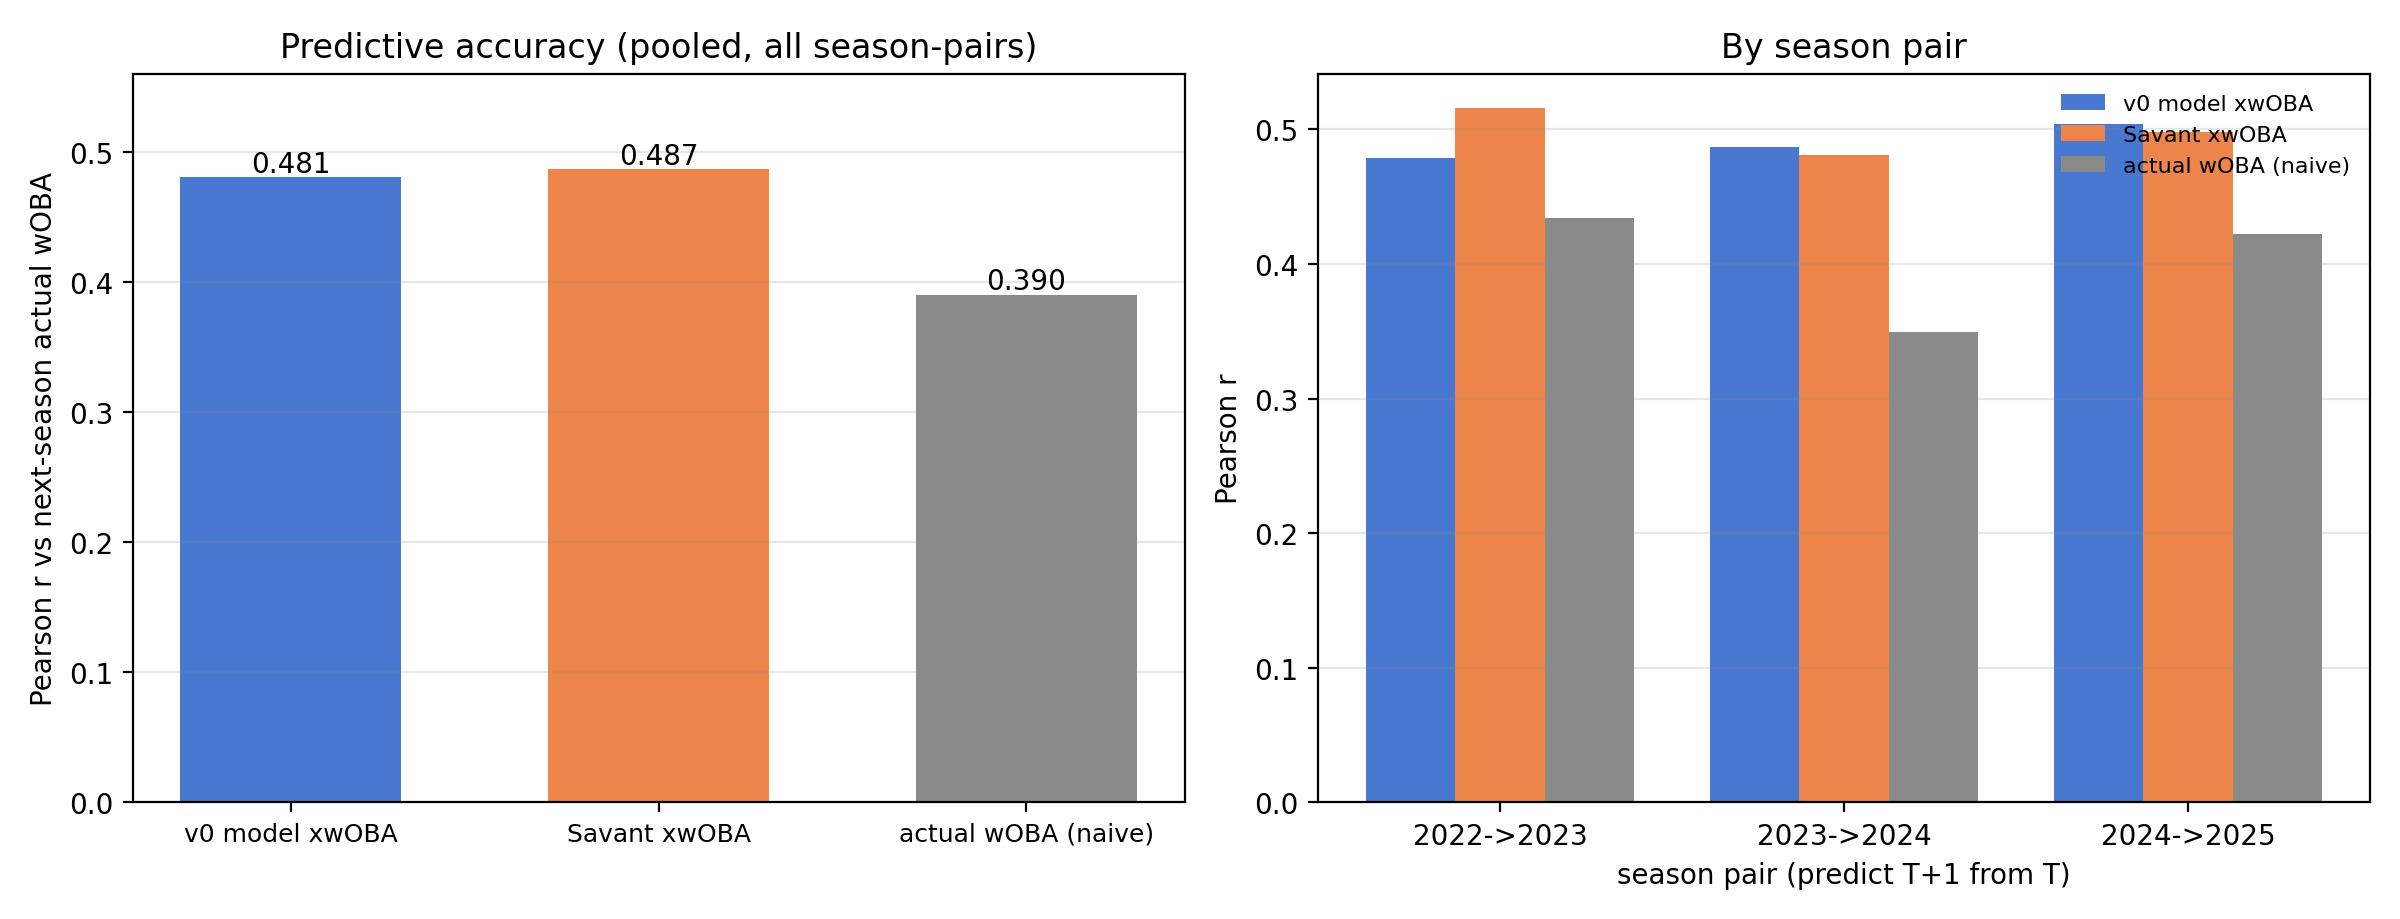

*Correlation with next season's actual wOBA — pooled (left) and by season pair (right).*

In [4]:
show_fig("benchmark/figures/predictive_accuracy.png",
         caption="Correlation with next season's actual wOBA — pooled (left) and by season pair (right).")

## So why parity, and what does it mean?

The way I read this: the 3-feature model is sitting right at Savant's information ceiling. Fiddling with the model won't beat Savant — the only way past this wall is to feed it inputs Savant doesn't have (spray direction, batter handedness), which is exactly what a future **v1** would add.

That gives me a concrete target for v1: pooled r above **0.487** against next-season actual wOBA, with the gap-CI clearly excluding 0.

But honestly, raw accuracy was never the whole point. Once I saw the parity result, the project pivoted toward two questions I find more interesting: how *confident* should we be in a given hitter's number, and what's their *true talent* underneath the noise? Those are Parts 3 and 4.

In [5]:
# guard: the numbers quoted in the prose above vs the artifacts — fails loudly on drift.
assert bm["n_pairs"] == 1058                              # "1,058 player-pairs" in the intro
assert round(bm["pooled"]["savant"]["r"], 3) == 0.487     # the v1 target quoted above
assert round(bm["pooled"]["model"]["r"], 3) == 0.481
assert b["ci95"][0] < 0 < b["ci95"][1]                    # "statistical parity"
per = bm["per_pair"]
assert (per["2022->2023"]["savant"]["r"] > per["2022->2023"]["model"]["r"]
        and per["2023->2024"]["model"]["r"] > per["2023->2024"]["savant"]["r"]
        and per["2024->2025"]["model"]["r"] > per["2024->2025"]["savant"]["r"])  # "Savant wins 22→23, v0 the other two"
print("prose numbers still match the artifacts")

prose numbers still match the artifacts
